# Exploratory Data Analysis (EDA)

### Data Wrangling (Pre-processing)

- Loading data from CSV, Excel, and SQL.
- Handling missing values (imputation or removal).
- Merging and joining disparate datasets.
- Grouping and aggregating data using .groupby()

### Statistical Foundations

- Central Tendency: Mean, median, and mode.
- Dispersion: Variance, standard deviation, and interquartile range (IQR).
- Correlations: Identifying relationships between variables.

### Data Visualization
- Distribution: Histograms and box plots to see data spread.
- Relationships: Scatter plots and heatmaps for correlations.
- Trends: Line charts for time-series data.

### The EDA Workflow
- Inspection: Use .head(), .info(), and .describe().
- Cleaning: Fix data types and remove duplicates.
- Analysis: Form hypotheses and test them with charts.
- Communication: Summarize insights clearly for non-technical stakeholders

After the EDA, build models and algorithms to explain patterns and generate business insights.

### Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

### Reading Data

In [3]:
# An EDA practice dataset with 50,250 rows and 27 columns
df = pd.read_csv("data.csv")

### Inspection and Understanding Data Structure

In [4]:
df.head()

,order_id,order_date,year,month,region,state,customer_id,customer_age,customer_income,customer_segment,product_category,sales_channel,payment_method,unit_price,quantity,discount_rate,shipping_cost,sales_amount,profit,profit_margin,customer_rating,return_flag,delivery_days,marketing_spend,ad_clicks,website_visits,employee_id
0,1,2024-03-30,2024,3,Midwest,IL,112955,39,"35,530.07",Family,Electronics,Third Party,Credit Card,306.92,4,0.10,1.60,"1,110.20",282.33,0.25,3.70,0,5,39.48,6,24,1008
1,2,2024-11-26,2024,11,West,AZ,106045,51,"162,346.52",Student,Electronics,Online,Credit Card,316.75,3,0.18,7.64,785.89,326.28,0.41,3.50,1,5,41.69,2,16,1111
2,3,2021-12-27,2021,12,South,FL,111098,35,"85,131.04",Family,Groceries,Online,PayPal,34.97,6,0.25,NaN,167.37,51.12,0.30,2.60,0,2,22.33,2,18,1128
3,4,2024-12-13,2024,12,South,FL,101373,55,"42,848.82",Young Professional,Electronics,In Store,Debit Card,170.02,4,0.07,1.85,637.72,250.14,0.39,4.70,0,0,28.67,5,16,1124
4,5,2024-12-26,2024,12,Northeast,NY,109958,38,"22,619.24",Business,Beauty,Online,Debit Card,22.43,3,0.06,6.99,70.31,19.14,0.27,2.20,0,4,66.10,10,22,1082


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50250 entries, 0 to 50249
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50250 non-null  int64  
 1   order_date        50250 non-null  str    
 2   year              50250 non-null  int64  
 3   month             50250 non-null  int64  
 4   region            50250 non-null  str    
 5   state             50250 non-null  str    
 6   customer_id       50250 non-null  int64  
 7   customer_age      50250 non-null  int64  
 8   customer_income   48741 non-null  float64
 9   customer_segment  50250 non-null  str    
 10  product_category  50250 non-null  str    
 11  sales_channel     50250 non-null  str    
 12  payment_method    48743 non-null  str    
 13  unit_price        50250 non-null  float64
 14  quantity          50250 non-null  int64  
 15  discount_rate     48742 non-null  float64
 16  shipping_cost     48743 non-null  float64
 17  sale

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,"50,250.00",NaN,NaN,NaN,"25,006.21","14,434.91",1.00,"12,506.25","25,009.50","37,508.75","50,000.00"
order_date,50250,1825,2025-04-30,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,"50,250.00",NaN,NaN,NaN,"2,023.00",1.42,"2,021.00","2,022.00","2,023.00","2,024.00","2,025.00"
month,"50,250.00",NaN,NaN,NaN,6.52,3.44,1.00,4.00,7.00,9.00,12.00
region,50250,4,South,16594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,50250,20,VA,3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,"50,250.00",NaN,NaN,NaN,"114,958.87","8,703.66","100,000.00","107,404.25","114,898.50","122,500.00","129,999.00"
customer_age,"50,250.00",NaN,NaN,NaN,38.29,12.29,18.00,29.00,38.00,47.00,85.00
customer_income,"48,741.00",NaN,NaN,NaN,"54,338.89","25,745.26","15,000.00","36,161.51","49,085.99","66,618.74","250,000.00"
customer_segment,50250,5,Family,15055,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Rows and columns:", df.shape)

Rows and columns: (50250, 27)


In [8]:
# Clean column names if needed
df.columns = (
    df.columns # Removes leading and trailing whitespace
    .str.strip() # Converts all characters to lowercase
    .str.lower() # Replaces internal spaces with underscores
    .str.replace(" ", "_")
)

df.columns

Index(['order_id', 'order_date', 'year', 'month', 'region', 'state',
       'customer_id', 'customer_age', 'customer_income', 'customer_segment',
       'product_category', 'sales_channel', 'payment_method', 'unit_price',
       'quantity', 'discount_rate', 'shipping_cost', 'sales_amount', 'profit',
       'profit_margin', 'customer_rating', 'return_flag', 'delivery_days',
       'marketing_spend', 'ad_clicks', 'website_visits', 'employee_id'],
      dtype='str')

### Check Duplicates

In [9]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df[df.duplicated()].head()

Number of duplicate rows: 250


,order_id,order_date,year,month,region,state,customer_id,customer_age,customer_income,customer_segment,product_category,sales_channel,payment_method,unit_price,quantity,discount_rate,shipping_cost,sales_amount,profit,profit_margin,customer_rating,return_flag,delivery_days,marketing_spend,ad_clicks,website_visits,employee_id
50000,33554,2021-12-25,2021,12,Midwest,WI,124906,45,"36,717.82",Family,Electronics,Online,Credit Card,111.25,1,0.13,5.34,101.79,31.43,0.31,2.90,0,7,8.92,0,15,1087
50001,9428,2024-06-13,2024,6,West,AZ,129130,24,"62,380.88",Student,Clothing,Mobile App,Credit Card,233.67,6,0.17,9.48,"1,166.15",250.03,0.21,4.60,0,4,37.85,6,16,1085
50002,200,2025-01-30,2025,1,South,TX,129286,41,"43,795.82",Retiree,Electronics,Online,Gift Card,103.96,4,NaN,13.86,398.93,65.73,0.17,4.60,0,4,38.52,4,21,1095
50003,12448,2022-10-24,2022,10,West,CO,113644,45,"58,410.30",Young Professional,Groceries,In Store,Debit Card,12.36,3,0.06,2.30,37.34,10.55,0.28,4.50,0,0,42.18,4,13,1122
50004,39490,2022-04-05,2022,4,South,GA,122502,33,"53,626.56",Student,Beauty,In Store,Debit Card,61.65,6,0.30,1.14,259.70,113.71,0.44,3.50,0,0,16.81,2,19,1023


In [10]:
# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (50000, 27)


### Check Missing Values

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
discount_rate,1500,3.00
customer_rating,1500,3.00
customer_income,1500,3.00
payment_method,1500,3.00
shipping_cost,1500,3.00
order_id,0,0.00
website_visits,0,0.00
ad_clicks,0,0.00
marketing_spend,0,0.00
delivery_days,0,0.00


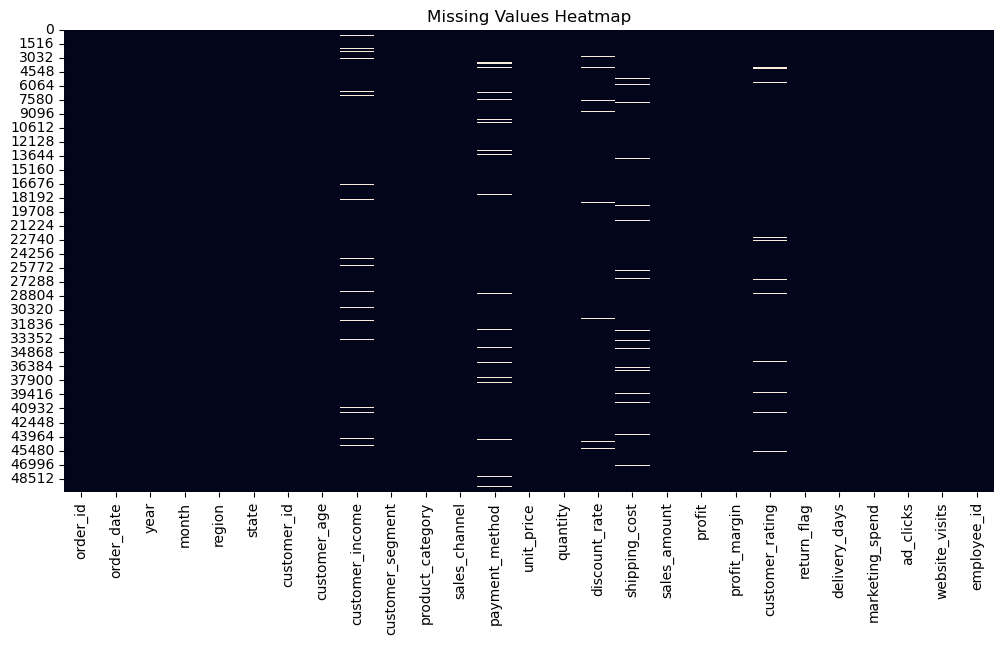

In [12]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Fix Data Types

In [13]:
# order_date is str
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[us]
 2   year              50000 non-null  int64         
 3   month             50000 non-null  int64         
 4   region            50000 non-null  str           
 5   state             50000 non-null  str           
 6   customer_id       50000 non-null  int64         
 7   customer_age      50000 non-null  int64         
 8   customer_income   48500 non-null  float64       
 9   customer_segment  50000 non-null  str           
 10  product_category  50000 non-null  str           
 11  sales_channel     50000 non-null  str           
 12  payment_method    48500 non-null  str           
 13  unit_price        50000 non-null  float64       
 14  quantity          50000 non-null 

In [16]:
# A checkpoint

df_new = df
df_new.head()

,order_id,order_date,year,month,region,state,customer_id,customer_age,customer_income,customer_segment,product_category,sales_channel,payment_method,unit_price,quantity,discount_rate,shipping_cost,sales_amount,profit,profit_margin,customer_rating,return_flag,delivery_days,marketing_spend,ad_clicks,website_visits,employee_id
0,1,2024-03-30,2024,3,Midwest,IL,112955,39,"35,530.07",Family,Electronics,Third Party,Credit Card,306.92,4,0.10,1.60,"1,110.20",282.33,0.25,3.70,0,5,39.48,6,24,1008
1,2,2024-11-26,2024,11,West,AZ,106045,51,"162,346.52",Student,Electronics,Online,Credit Card,316.75,3,0.18,7.64,785.89,326.28,0.41,3.50,1,5,41.69,2,16,1111
2,3,2021-12-27,2021,12,South,FL,111098,35,"85,131.04",Family,Groceries,Online,PayPal,34.97,6,0.25,NaN,167.37,51.12,0.30,2.60,0,2,22.33,2,18,1128
3,4,2024-12-13,2024,12,South,FL,101373,55,"42,848.82",Young Professional,Electronics,In Store,Debit Card,170.02,4,0.07,1.85,637.72,250.14,0.39,4.70,0,0,28.67,5,16,1124
4,5,2024-12-26,2024,12,Northeast,NY,109958,38,"22,619.24",Business,Beauty,Online,Debit Card,22.43,3,0.06,6.99,70.31,19.14,0.27,2.20,0,4,66.10,10,22,1082


### Handling Missing Values

In [17]:
# Numeric columns
numeric_cols = df_new.select_dtypes(include=np.number).columns

# Fill numeric missing values with median
for col in numeric_cols:
    df_new[col] = df_new[col].fillna(df_new[col].median())

In [18]:
# Categorical columns
categorical_cols = df_new.select_dtypes(include="str").columns

# Fill categorical missing values with mode
for col in categorical_cols:
    df_new[col] = df_new[col].fillna(df_new[col].mode()[0])

In [19]:
df_new.isna().sum().sum()

np.int64(0)

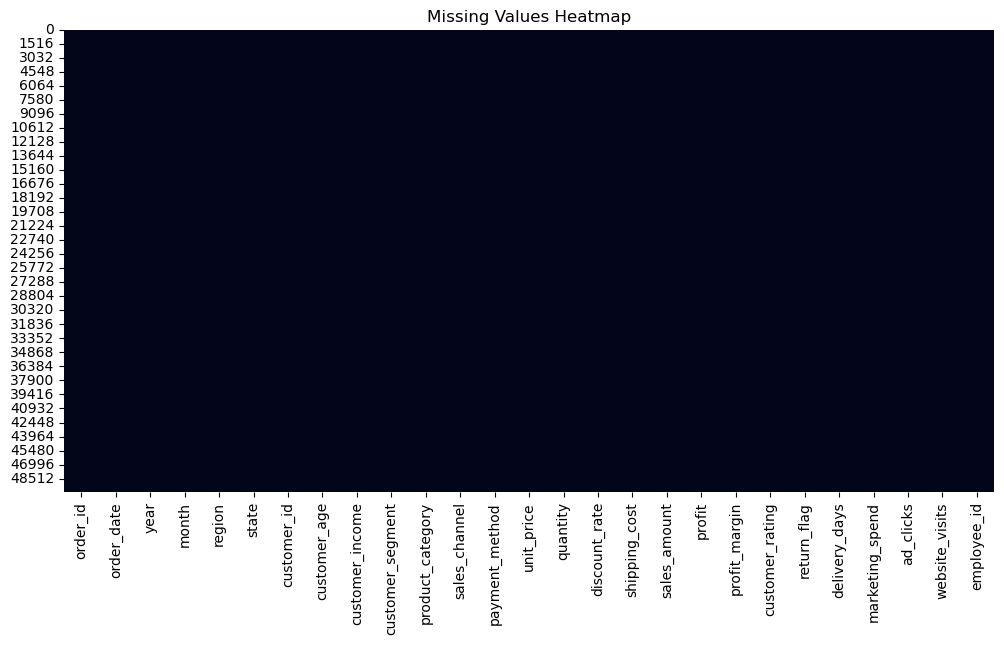

In [20]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_new.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Create New Features

In [21]:
df_new["year"] = df_new["order_date"].dt.year
df_new["month"] = df_new["order_date"].dt.month
df_new["month_name"] = df_new["order_date"].dt.month_name()
df_new["quarter"] = df_new["order_date"].dt.quarter
df_new["day_of_week"] = df_new["order_date"].dt.day_name()

df_new["is_returned"] = df_new["return_flag"].map({1: "Returned", 0: "Not Returned"})

df_new["revenue_per_unit"] = df_new["sales_amount"] / df_new["quantity"]

df_new["profit_per_unit"] = df_new["profit"] / df_new["quantity"]

df_new.head()

,order_id,order_date,year,month,region,state,customer_id,customer_age,customer_income,customer_segment,product_category,sales_channel,payment_method,unit_price,quantity,discount_rate,shipping_cost,sales_amount,profit,profit_margin,customer_rating,return_flag,delivery_days,marketing_spend,ad_clicks,website_visits,employee_id,month_name,quarter,day_of_week,is_returned,revenue_per_unit,profit_per_unit
0,1,2024-03-30,2024,3,Midwest,IL,112955,39,"35,530.07",Family,Electronics,Third Party,Credit Card,306.92,4,0.10,1.60,"1,110.20",282.33,0.25,3.70,0,5,39.48,6,24,1008,March,1,Saturday,Not Returned,277.55,70.58
1,2,2024-11-26,2024,11,West,AZ,106045,51,"162,346.52",Student,Electronics,Online,Credit Card,316.75,3,0.18,7.64,785.89,326.28,0.41,3.50,1,5,41.69,2,16,1111,November,4,Tuesday,Returned,261.96,108.76
2,3,2021-12-27,2021,12,South,FL,111098,35,"85,131.04",Family,Groceries,Online,PayPal,34.97,6,0.25,6.43,167.37,51.12,0.30,2.60,0,2,22.33,2,18,1128,December,4,Monday,Not Returned,27.89,8.52
3,4,2024-12-13,2024,12,South,FL,101373,55,"42,848.82",Young Professional,Electronics,In Store,Debit Card,170.02,4,0.07,1.85,637.72,250.14,0.39,4.70,0,0,28.67,5,16,1124,December,4,Friday,Not Returned,159.43,62.53
4,5,2024-12-26,2024,12,Northeast,NY,109958,38,"22,619.24",Business,Beauty,Online,Debit Card,22.43,3,0.06,6.99,70.31,19.14,0.27,2.20,0,4,66.10,10,22,1082,December,4,Thursday,Not Returned,23.44,6.38


### KPI Summary

In [22]:
total_revenue = df_new["sales_amount"].sum()
total_profit = df_new["profit"].sum()
total_orders = df_new["order_id"].nunique()
average_order_value = df_new["sales_amount"].mean()
return_rate = df_new["return_flag"].mean() * 100
average_rating = df_new["customer_rating"].mean()

In [23]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Average Order Value",
        "Return Rate (%)",
        "Average Customer Rating"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_orders,
        average_order_value,
        return_rate,
        average_rating
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,"25,367,498.99"
1,Total Profit,"7,019,728.63"
2,Total Orders,"50,000.00"
3,Average Order Value,507.35
4,Return Rate (%),8.29
5,Average Customer Rating,3.96


### Numerical Variable Summary

In [24]:
df_new[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,"50,000.00","25,000.50","14,433.90",1.00,"12,500.75","25,000.50","37,500.25","50,000.00"
year,"50,000.00","2,023.00",1.42,"2,021.00","2,022.00","2,023.00","2,024.00","2,025.00"
month,"50,000.00",6.52,3.44,1.00,4.00,7.00,9.00,12.00
customer_id,"50,000.00","114,956.64","8,703.81","100,000.00","107,402.00","114,900.50","122,496.25","129,999.00"
customer_age,"50,000.00",38.29,12.29,18.00,29.00,38.00,47.00,85.00
customer_income,"50,000.00","54,171.67","25,373.63","15,000.00","36,567.49","49,079.01","65,919.55","250,000.00"
unit_price,"50,000.00",171.89,238.96,5.00,36.41,75.39,199.09,"3,000.00"
quantity,"50,000.00",3.30,1.52,1.00,2.00,3.00,4.00,11.00
discount_rate,"50,000.00",0.14,0.11,0.00,0.06,0.11,0.19,0.72
shipping_cost,"50,000.00",7.42,5.72,0.00,2.51,6.43,11.58,33.14


### Categorical Variable Summary

In [25]:
for col in categorical_cols:
    print("\n", col.upper())
    print(df[col].value_counts())


 REGION
region
South        16513
Midwest      12545
Northeast    11016
West          9926
Name: count, dtype: int64

 STATE
state
VA    3340
GA    3333
TX    3289
NC    3284
FL    3267
MN    2546
OH    2512
WI    2510
MI    2498
IL    2479
NY    2227
MA    2219
PA    2203
NJ    2190
CT    2177
CO    2042
WA    2015
CA    2011
AZ    1976
OR    1882
Name: count, dtype: int64

 CUSTOMER_SEGMENT
customer_segment
Family                14972
Young Professional    12541
Business               9125
Student                7447
Retiree                5915
Name: count, dtype: int64

 PRODUCT_CATEGORY
product_category
Groceries      9768
Electronics    8812
Clothing       8367
Furniture      6373
Sports         5999
Beauty         5072
Books          5009
GROCERIES       124
ELECTRONICS     116
CLOTHING         96
FURNITURE        78
BEAUTY           66
SPORTS           63
BOOKS            57
Name: count, dtype: int64

 SALES_CHANNEL
sales_channel
Online           18874
In Store         14795
Mo

### Univariate Analysis

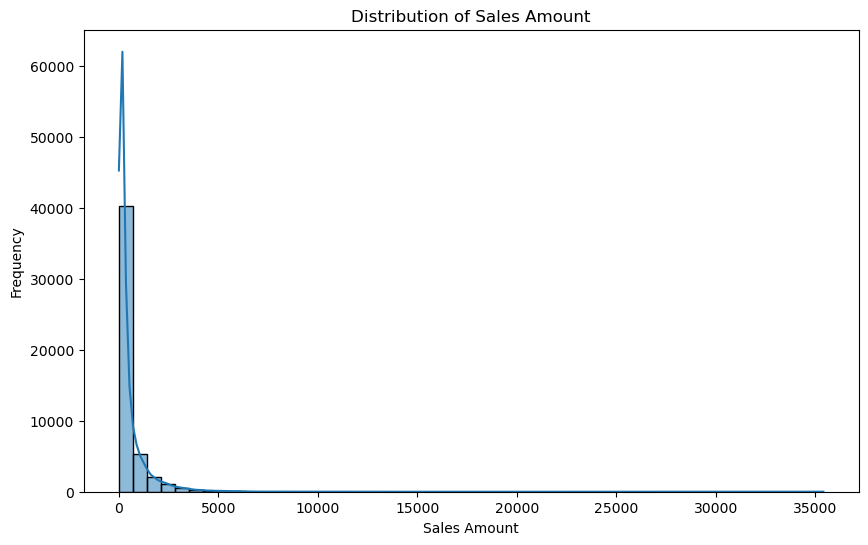

In [26]:
# Distribution of sales amount
plt.figure(figsize=(10, 6))
sns.histplot(df_new["sales_amount"], bins=50, kde=True)
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

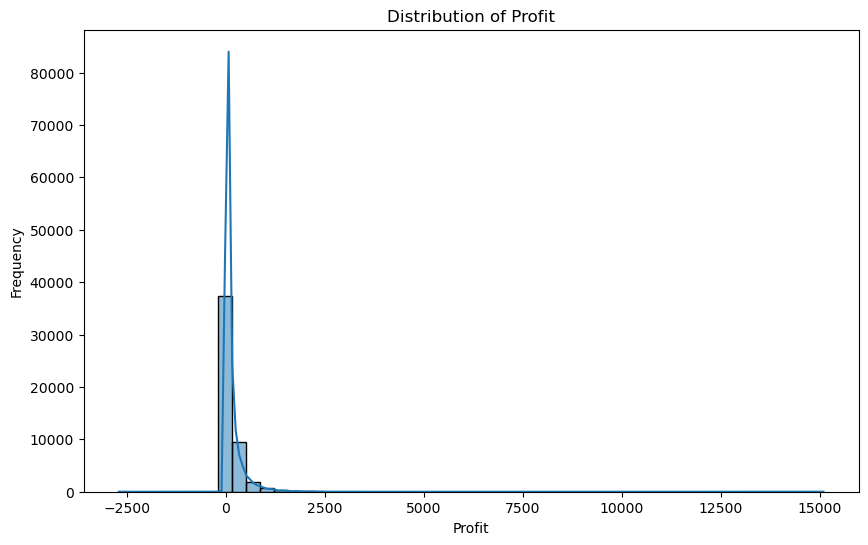

In [27]:
# Profit distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_new["profit"], bins=50, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

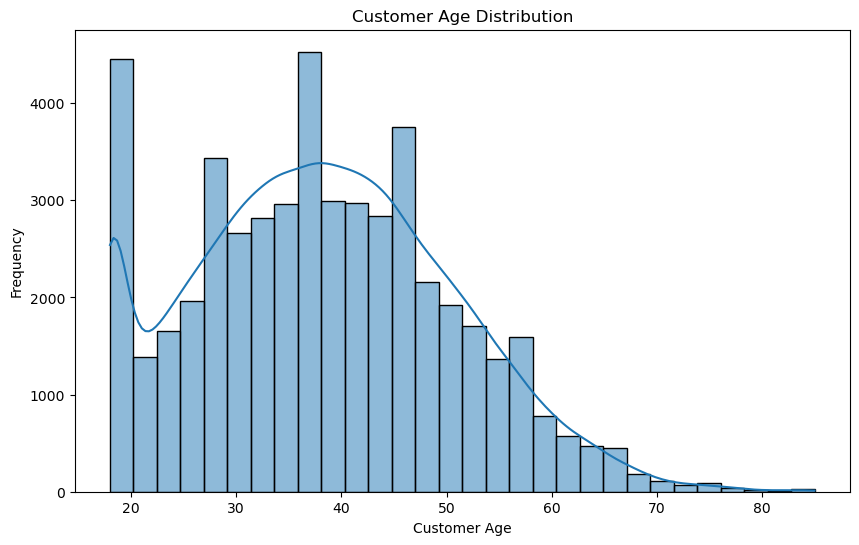

In [28]:
# Customer age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_new["customer_age"], bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.show()

### Categorical Countplots

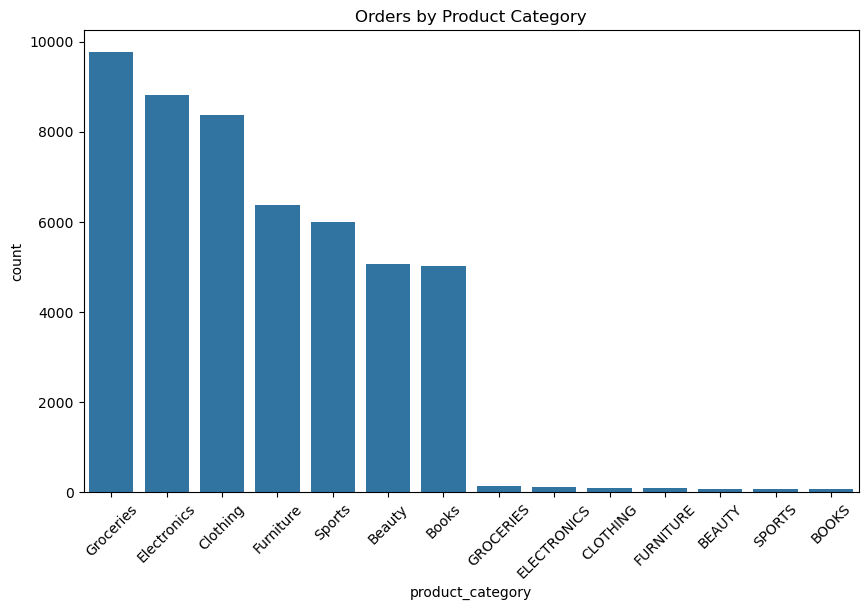

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_new, x="product_category", order=df_new["product_category"].value_counts().index)
plt.title("Orders by Product Category")
plt.xticks(rotation=45)
plt.show()

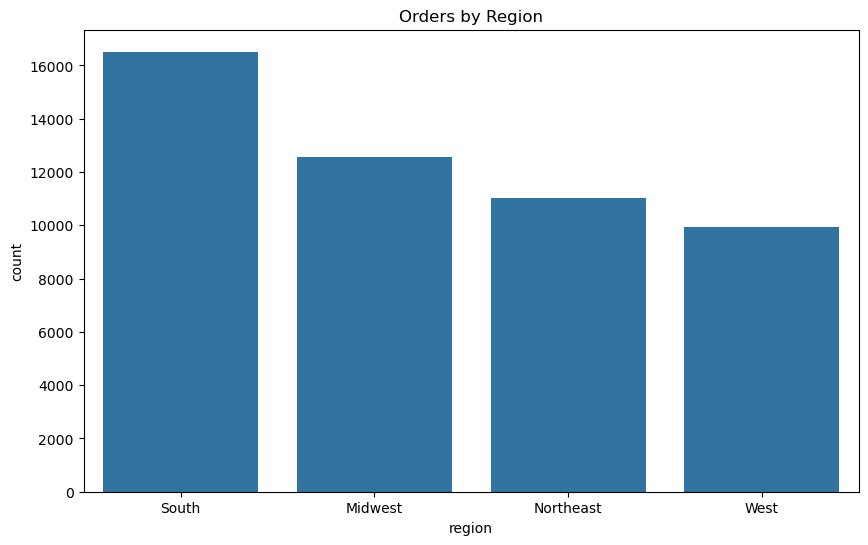

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_new, x="region", order=df_new["region"].value_counts().index)
plt.title("Orders by Region")
plt.show()

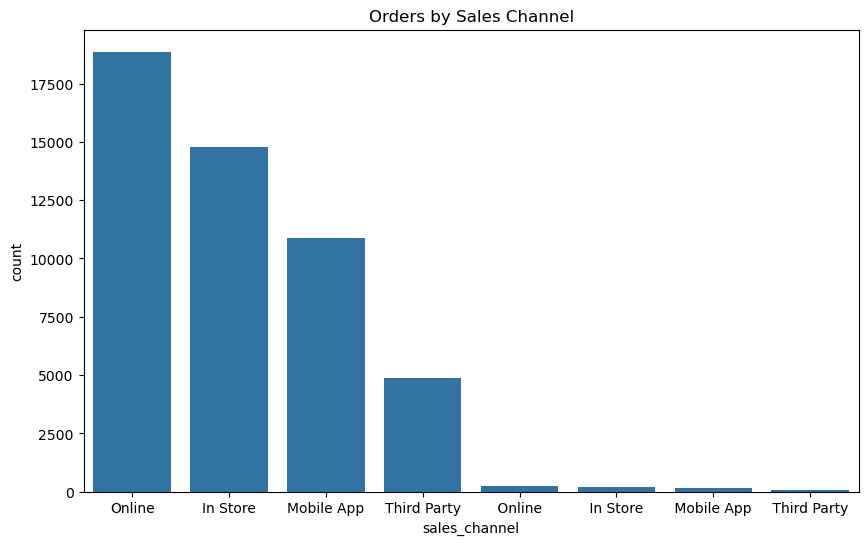

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_new, x="sales_channel", order=df_new["sales_channel"].value_counts().index)
plt.title("Orders by Sales Channel")
plt.show()

### Revenue by Product Category

In [32]:
category_revenue = (
    df_new.groupby("product_category", as_index=False)
    .agg(
        total_revenue=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("sales_amount", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_revenue

,product_category,total_revenue,total_profit,total_orders,avg_order_value
9,Furniture,"10,192,767.08","2,815,019.45",6373,"1,599.37"
7,Electronics,"8,186,685.43","2,262,932.75",8812,929.04
13,Sports,"1,974,257.99","547,753.70",5999,329.10
5,Clothing,"1,891,258.12","526,480.99",8367,226.04
11,Groceries,"1,342,364.64","374,168.69",9768,137.42
2,Beauty,"907,859.01","249,641.40",5072,178.99
3,Books,"558,799.23","154,944.49",5009,111.56
8,FURNITURE,"128,647.24","37,532.32",78,"1,649.32"
6,ELECTRONICS,"106,486.38","29,981.64",116,917.99
4,CLOTHING,"20,979.59","5,768.53",96,218.54


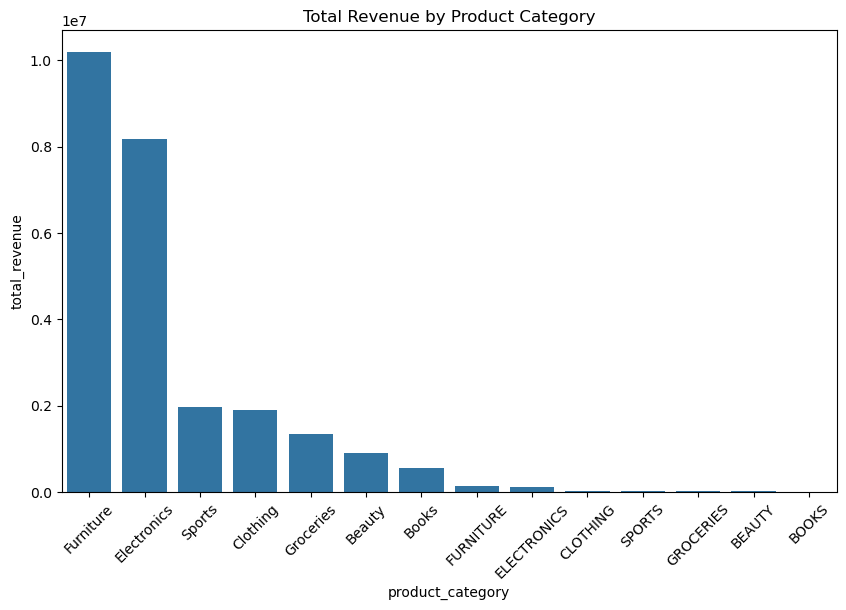

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue, x="product_category", y="total_revenue")
plt.title("Total Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()

### Revenue by Region

In [34]:
region_revenue = (
    df_new.groupby("region", as_index=False)
    .agg(
        total_revenue=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        return_rate=("return_flag", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

region_revenue["return_rate"] = region_revenue["return_rate"] * 100

In [35]:
region_revenue

,region,total_revenue,total_profit,total_orders,return_rate
2,South,"8,238,439.55","2,282,290.61",16513,8.19
0,Midwest,"6,504,257.75","1,781,504.96",12545,7.88
1,Northeast,"5,720,972.65","1,588,815.98",11016,8.39
3,West,"4,903,829.04","1,367,117.08",9926,8.87


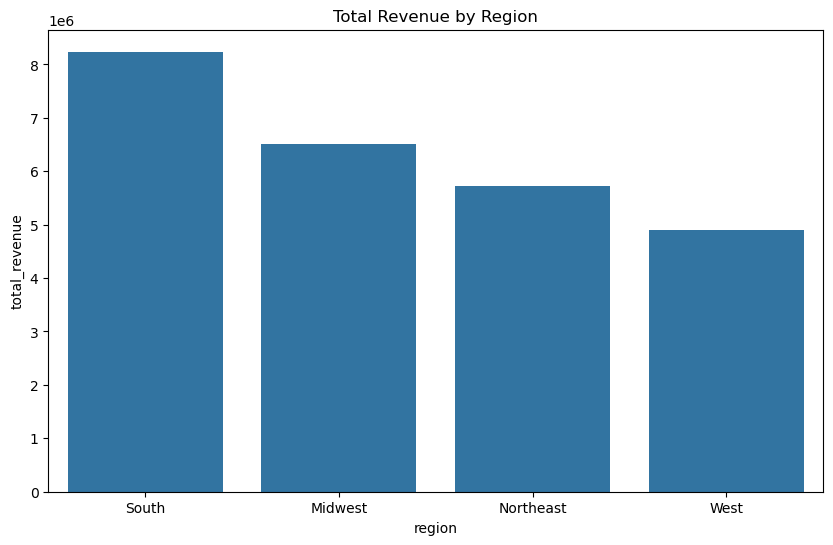

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=region_revenue, x="region", y="total_revenue")
plt.title("Total Revenue by Region")
plt.show()

### Sales Channel Performance